## **Data Exploration**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
comments = pd.read_csv(
    "/content/drive/MyDrive/Text Data Analytics (Youtube Case-Study)/UScomments.csv",
    engine="python",
    on_bad_lines="skip"
)

In [ ]:
comments.head()

,video_id,comment_text,likes,replies
0,XpVt6Z1Gjjo,Logan Paul it's yo big day ‼️‼️‼️,4,0
1,XpVt6Z1Gjjo,I've been following you from the start of your...,3,0
2,XpVt6Z1Gjjo,Say hi to Kong and maverick for me,3,0
3,XpVt6Z1Gjjo,MY FAN . attendance,3,0
4,XpVt6Z1Gjjo,trending 😉,3,0


In [ ]:
comments['comment_text']

,comment_text
0,Logan Paul it's yo big day ‼️‼️‼️
1,I've been following you from the start of your...
2,Say hi to Kong and maverick for me
3,MY FAN . attendance
4,trending 😉
...,...
691390,Лучшая
691391,qu'est ce que j'aimerais que tu viennes à Roan...
691392,Ven a mexico! 😍 te amo LP
691393,Islığı yeter...


In [ ]:
comments.groupby('comment_text').size()

,0
comment_text,
,2
'Literally' 'like' my bestfriend\nCamila wut?🤔,3
*But I Will Tell You If I Don't Like You* 🔥,1
*WHAT THE FU-*,1
*family friendly pg clean*,1
...,...
🦊,1
🦋🦋🦋🦋🦋🦋🦋🦋🦋🦋🦋 Sam,1
🦌,1


In [ ]:
type(comments)

pandas.core.frame.DataFrame

In [ ]:
comments.dtypes


,0
video_id,object
comment_text,object
likes,object
replies,object


In [ ]:
comments.shape

(691395, 4)

In [ ]:
comments.columns


Index(['video_id', 'comment_text', 'likes', 'replies'], dtype='object')

In [ ]:
comments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691395 entries, 0 to 691394
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   video_id      691395 non-null  object
 1   comment_text  691369 non-null  object
 2   likes         691395 non-null  object
 3   replies       691395 non-null  object
dtypes: object(4)
memory usage: 21.1+ MB


In [ ]:

comments.describe()

,video_id,comment_text,likes,replies
count,691395,691369,691395,691395
unique,2266,434070,1060,369
top,XpVt6Z1Gjjo,Lol,0,0
freq,800,310,563748,649361


In [ ]:
comments.describe(include='all')

,video_id,comment_text,likes,replies
count,691395,691369,691395,691395
unique,2266,434070,1060,369
top,XpVt6Z1Gjjo,Lol,0,0
freq,800,310,563748,649361


In [ ]:
comments.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
691390,True
691391,True
691392,True
691393,False


In [ ]:
comments['video_id'].nunique()


2266

In [ ]:
comments["comment_text"].value_counts()

,count
comment_text,
Lol,310
Hi,303
<3,255
Wow,255
Nice,200
...,...
Linus Catch Tips,1
He happy cause he in a movie,1
aw geez rick this guy is the face of YouTube.,1


####**Handling Missing Values** :

In [ ]:
comments.isnull()

,video_id,comment_text,likes,replies
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
...,...,...,...,...
691390,False,False,False,False
691391,False,False,False,False
691392,False,False,False,False
691393,False,False,False,False


In [ ]:
comments.isnull().sum()

,0
video_id,0
comment_text,26
likes,0
replies,0


In [ ]:
comments.dropna(inplace = True)

In [ ]:
comments.isnull().sum()

,0
video_id,0
comment_text,0
likes,0
replies,0


## **Lexicon-Based Sentiment Analysis with NLTK VADER:**



- For this project, sentiment analysis is performed using NLTK’s VADER (Valence Aware Dictionary and sEntiment Reasoner), a pre-trained sentiment model.
- VADER is specifically designed for social media text and short informal comments.

In [ ]:
!pip install nltk

In [ ]:
import nltk

In [ ]:
nltk.download("vader_lexicon")    # vader_lexicon is a dictionary have words and their senitment score

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [ ]:
sia = SentimentIntensityAnalyzer()

In [ ]:
comments["comment_text"]

,comment_text
0,Logan Paul it's yo big day ‼️‼️‼️
1,I've been following you from the start of your...
2,Say hi to Kong and maverick for me
3,MY FAN . attendance
4,trending 😉
...,...
691390,Лучшая
691391,qu'est ce que j'aimerais que tu viennes à Roan...
691392,Ven a mexico! 😍 te amo LP
691393,Islığı yeter...


In [ ]:
sia.polarity_scores("MY FAN . attendance")

{'neg': 0.0, 'neu': 0.397, 'pos': 0.603, 'compound': 0.4648}

In [ ]:
sia.polarity_scores("MY FAN . attendance")["compound"]

0.4648

In [ ]:
sentiment_scores = []

for comment in comments["comment_text"]:
    score = sia.polarity_scores(str(comment))["compound"]
    sentiment_scores.append(score)


In [ ]:
comments["Polarity"] = sentiment_scores

In [ ]:
comments.head()

,video_id,comment_text,likes,replies,Polarity
0,XpVt6Z1Gjjo,Logan Paul it's yo big day ‼️‼️‼️,4,0,0.0000
1,XpVt6Z1Gjjo,I've been following you from the start of your...,3,0,0.0000
2,XpVt6Z1Gjjo,Say hi to Kong and maverick for me,3,0,0.0000
3,XpVt6Z1Gjjo,MY FAN . attendance,3,0,0.4648
4,XpVt6Z1Gjjo,trending 😉,3,0,0.0000


## **Word Cloud Analysis** :

In [ ]:
filter_positive = (comments["Polarity"] >= 0.8) & (comments["Polarity"] <= 1.0)

In [ ]:
comments[filter_positive]

,video_id,comment_text,likes,replies,Polarity
24,XpVt6Z1Gjjo,I love Logan and Jake so much and thay are so ...,1,0,0.8769
27,XpVt6Z1Gjjo,if you get allot of diss likes do you get on t...,0,0,0.8283
29,XpVt6Z1Gjjo,I love you so much I love to meet you But I li...,0,0,0.9820
45,XpVt6Z1Gjjo,"This looks like a great video, but after you a...",0,0,0.9226
57,XpVt6Z1Gjjo,Congrats Logan love u so much someday I would ...,0,0,0.9337
...,...,...,...,...,...
691307,EoejGgUNmVU,"Fabulous video, just so wonderful live.It's so...",0,0,0.9329
691317,EoejGgUNmVU,I love each and every version of this song. LP...,0,0,0.8402
691319,EoejGgUNmVU,Absolutely fabulous ! LP has the genius to ren...,0,0,0.9397
691340,EoejGgUNmVU,Beautiful LP! You are gorgeous!,0,0,0.8585


In [ ]:
comments_positive = comments[filter_positive]

In [ ]:
comments.shape

(691369, 5)

In [ ]:
comments[filter_positive]

,video_id,comment_text,likes,replies,Polarity
24,XpVt6Z1Gjjo,I love Logan and Jake so much and thay are so ...,1,0,0.8769
27,XpVt6Z1Gjjo,if you get allot of diss likes do you get on t...,0,0,0.8283
29,XpVt6Z1Gjjo,I love you so much I love to meet you But I li...,0,0,0.9820
45,XpVt6Z1Gjjo,"This looks like a great video, but after you a...",0,0,0.9226
57,XpVt6Z1Gjjo,Congrats Logan love u so much someday I would ...,0,0,0.9337
...,...,...,...,...,...
691307,EoejGgUNmVU,"Fabulous video, just so wonderful live.It's so...",0,0,0.9329
691317,EoejGgUNmVU,I love each and every version of this song. LP...,0,0,0.8402
691319,EoejGgUNmVU,Absolutely fabulous ! LP has the genius to ren...,0,0,0.9397
691340,EoejGgUNmVU,Beautiful LP! You are gorgeous!,0,0,0.8585


In [ ]:
filter_negative = (comments["Polarity"] >= -1.0) & (comments["Polarity"] <= -0.8)

In [ ]:
comments[filter_negative]

,video_id,comment_text,likes,replies,Polarity
35,XpVt6Z1Gjjo,"Evan is being a douch Logans getting pissed, L...",0,0,-0.9421
63,XpVt6Z1Gjjo,No one fucking cares. You're a 12 year old. Th...,0,0,-0.9005
113,cLdxuaxaQwc,OK guys i get that the word was once used as a...,0,0,-0.9470
114,cLdxuaxaQwc,pewdiepie had nothing to be sorry about. ever...,0,0,-0.8062
115,cLdxuaxaQwc,I think other YouTube's who are hatting at him...,0,0,-0.9457
...,...,...,...,...,...
691249,qRoVlH1OcI4,I swear that Trump supporters would eat warm d...,0,0,-0.8979
691254,qRoVlH1OcI4,there are many reasons for taking a knee to th...,0,0,-0.9065
691257,qRoVlH1OcI4,it's odd to think how many people keep asking ...,0,0,-0.9538
691258,qRoVlH1OcI4,So when we take a knee for fallen soldiers tha...,0,0,-0.8519


In [ ]:
comments_negative = comments[filter_negative]

In [ ]:
comments_negative.shape

(16148, 5)

In [ ]:
!pip install wordcloud

In [ ]:
from wordcloud import WordCloud, STOPWORDS

In [ ]:
comments_positive["comment_text"]

,comment_text
24,I love Logan and Jake so much and thay are so ...
27,if you get allot of diss likes do you get on t...
29,I love you so much I love to meet you But I li...
45,"This looks like a great video, but after you a..."
57,Congrats Logan love u so much someday I would ...
...,...
691307,"Fabulous video, just so wonderful live.It's so..."
691317,I love each and every version of this song. LP...
691319,Absolutely fabulous ! LP has the genius to ren...
691340,Beautiful LP! You are gorgeous!


In [ ]:
type(comments_positive["comment_text"])

pandas.core.series.Series

In [ ]:
# Converting the series into string data type-
" ".join(comments_positive["comment_text"])

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
total_positive_comments = " ".join(comments_positive["comment_text"])

In [ ]:
total_positive_comments[0:1000]

"I love Logan and Jake so much and thay are so amazing and I look up to them so much 😍💋💙👍 if you get allot of diss likes do you get on the top comments? lets see diss like this please I love you so much I love to meet you But I live in Israel You really inspire me I really like your channel Keep doing what you do\\nBecause everyone loves it and will be Unique and Pashan will be creative and I hope you will see it bye This looks like a great video, but after you are done would you be kind enough to check out my new YouTube channel and give me some feedback? Maybe even subscribing? :) Congrats Logan love u so much someday I would love to meet u #1 fan of the logang ❤️ Well done I LOVE! You so much :D I am very happy for this man and we need to spread more love. United we stand, divided we fall. And this could in all honestly become a good thing for you. You sit on a platform where you could really educate people especially when so many of your fans seem to think it's okay to be said. Rea

In [ ]:
set(STOPWORDS)

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'all',
 'also',
 'am',
 'an',
 'and',
 'any',
 'are',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 "can't",
 'cannot',
 'com',
 'could',
 "couldn't",
 'did',
 "didn't",
 'do',
 'does',
 "doesn't",
 'doing',
 "don't",
 'down',
 'during',
 'each',
 'else',
 'ever',
 'few',
 'for',
 'from',
 'further',
 'get',
 'had',
 "hadn't",
 'has',
 "hasn't",
 'have',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'hence',
 'her',
 'here',
 "here's",
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 "how's",
 'however',
 'http',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 "isn't",
 'it',
 "it's",
 'its',
 'itself',
 'just',
 'k',
 "let's",
 'like',
 'me',
 'more',
 'most',
 "mustn't",
 'my',
 'myself',
 'no',
 'nor',
 'not',
 'of',
 'off',
 'on',
 'once',
 'only',
 'or',
 'other',
 'otherwise',
 'ought',
 'our',
 

In [ ]:
wordcloud_positive = WordCloud(stopwords = set(STOPWORDS)).generate(total_positive_comments)

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

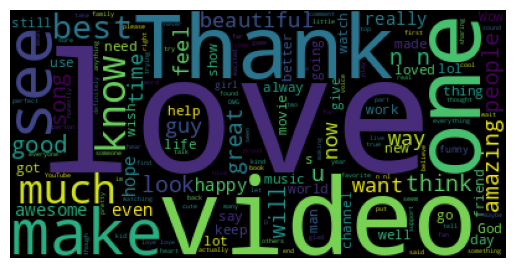

In [ ]:
plt.imshow(wordcloud_positive)
plt.axis("off")

In [ ]:
" ".join(comments_negative["comment_text"])

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
total_negative_comments = " ".join(comments_negative["comment_text"])

In [ ]:
total_negative_comments[0:1000]

"Evan is being a douch Logans getting pissed, Logan should have went to smash his game system then evan would have cried 😂 & Evans not gonna be able to take care of a pitbull tell his ass no, its gonna kill kong !!! No one fucking cares. You're a 12 year old. There comes a point where you're too old for the whole I'm so goofy and fun every second of every day schtick. Yeah you're impressing douchey 14 year olds who waste their lives on YouTube but to the real world you and your fucktard brother are nothing more than a pair of over privileged, white privileged toddlers. Grow the fuck up man. You think this will be your life forever. One day you're going to face the real world and realize you can't just jump around and scream your way to a real job. Or you can't hair flip your way out of an inevitable date rape charge. OK guys i get that the word was once used as a demeaning term and that the history of that word will never change, yes pewds fucked up but still it quite obviously wasn't 

In [ ]:
wordcloud_negative = WordCloud(stopwords = set(STOPWORDS)).generate(total_negative_comments)

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

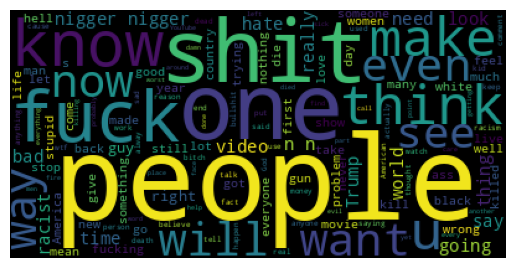

In [ ]:
plt.imshow(wordcloud_negative)
plt.axis("off")

## **Emoji's Analysis:**

In [ ]:
! pip install emoji==2.14.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.6/590.6 kB 15.0 MB/s eta 0:00:00


In [ ]:
import emoji

In [ ]:
emoji.__version__

'2.14.1'

In [ ]:
comments.head()


,video_id,comment_text,likes,replies,Polarity
0,XpVt6Z1Gjjo,Logan Paul it's yo big day ‼️‼️‼️,4,0,0.0000
1,XpVt6Z1Gjjo,I've been following you from the start of your...,3,0,0.0000
2,XpVt6Z1Gjjo,Say hi to Kong and maverick for me,3,0,0.0000
3,XpVt6Z1Gjjo,MY FAN . attendance,3,0,0.4648
4,XpVt6Z1Gjjo,trending 😉,3,0,0.0000


In [ ]:
emoji.emoji_list("trending 😉")

[{'match_start': 9, 'match_end': 10, 'emoji': '😉'}]

In [ ]:
emojis_info = emoji.emoji_list("trending 😉")

In [ ]:
[item["emoji"] for item in emojis_info]

['😉']

In [ ]:
comments["comment_text"]

,comment_text
0,Logan Paul it's yo big day ‼️‼️‼️
1,I've been following you from the start of your...
2,Say hi to Kong and maverick for me
3,MY FAN . attendance
4,trending 😉
...,...
691390,Лучшая
691391,qu'est ce que j'aimerais que tu viennes à Roan...
691392,Ven a mexico! 😍 te amo LP
691393,Islığı yeter...


In [ ]:
all_emojis_found = []

for comment in comments["comment_text"]:
  emojis_info = emoji.emoji_list(comment)
  emojis_found = [item["emoji"] for item in emojis_info]
  all_emojis_found.extend(emojis_found)

In [ ]:
all_emojis_found[0 : 10]

['‼️', '‼️', '‼️', '😉', '😭', '👍🏻', '❤️', '😍', '💋', '💙']

In [ ]:
len(all_emojis_found)

288886

In [ ]:
# For every emoji we need a fequency count

from collections import Counter

In [ ]:
emojis_count_list_top10 = Counter(all_emojis_found).most_common(10)

In [ ]:
emojis_count_list_top10

[('😂', 36998),
 ('😍', 33453),
 ('❤️', 16911),
 ('❤', 14167),
 ('🔥', 8694),
 ('😭', 8398),
 ('😘', 5545),
 ('💖', 5362),
 ('💕', 5147),
 ('👍', 4251)]

In [ ]:
emojis = [emoji for emoji , count in emojis_count_list_top10]

counts = [count for emoji , count in emojis_count_list_top10]

In [ ]:
emojis

['😂', '😍', '❤️', '❤', '🔥', '😭', '😘', '💖', '💕', '👍']

In [ ]:
counts

[36998, 33453, 16911, 14167, 8694, 8398, 5545, 5362, 5147, 4251]

In [ ]:
!pip install plotly

In [ ]:
import plotly.graph_objs as go
from plotly.offline import iplot

In [ ]:
go.Bar(x = emojis , y = counts)

Bar({
    'x': [😂, 😍, ❤️, ❤, 🔥, 😭, 😘, 💖, 💕, 👍],
    'y': [36998, 33453, 16911, 14167, 8694, 8398, 5545, 5362, 5147, 4251]
})

In [ ]:
iplot([go.Bar(x = emojis , y = counts)])

#####  **Conclusions** : Majority of the customers are happy as most of them are using emojis like: funny , love , heart , outstanding..

## **Collect entire data of Youtube : Data Collection**

In [ ]:
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path = '/content/drive/MyDrive/Text Data Analytics (Youtube Case-Study)/additional_data'
files = os.listdir(path)
print(files)

['CAvideos.csv', 'CA_category_id.json', 'DE_category_id.json', 'DEvideos.csv', 'FR_category_id.json', 'FRvideos.csv', 'GB_category_id.json', 'GBvideos.csv', 'INvideos.csv', 'IN_category_id.json', 'JP_category_id.json', 'JPvideos.csv', 'KRvideos.csv', 'KR_category_id.json', 'MX_category_id.json', 'MXvideos.csv', 'RU_category_id.json', 'RUvideos.csv', 'US_category_id.json', 'USvideos.csv']


In [ ]:
files


['CAvideos.csv',
 'CA_category_id.json',
 'DE_category_id.json',
 'DEvideos.csv',
 'FR_category_id.json',
 'FRvideos.csv',
 'GB_category_id.json',
 'GBvideos.csv',
 'INvideos.csv',
 'IN_category_id.json',
 'JP_category_id.json',
 'JPvideos.csv',
 'KRvideos.csv',
 'KR_category_id.json',
 'MX_category_id.json',
 'MXvideos.csv',
 'RU_category_id.json',
 'RUvideos.csv',
 'US_category_id.json',
 'USvideos.csv']

In [ ]:
## extracting csv files only from above list ..

files_csv = [file for file in files if '.csv' in file]

In [ ]:
files_csv

['CAvideos.csv',
 'DEvideos.csv',
 'FRvideos.csv',
 'GBvideos.csv',
 'INvideos.csv',
 'JPvideos.csv',
 'KRvideos.csv',
 'MXvideos.csv',
 'RUvideos.csv',
 'USvideos.csv']

In [ ]:
import warnings
from warnings import filterwarnings
filterwarnings('ignore')

**Note :** encoding may change depending upon data  , country data , sometimes regional data as well

In [ ]:
full_df = pd.DataFrame()

for file in files_csv:
  current_df = pd.read_csv(path + "/" + file, encoding = "iso-8859-1", on_bad_lines='skip')

  full_df = pd.concat([full_df , current_df], ignore_index = True)


In [ ]:
full_df.shape

(375942, 16)

**This `full_df` is a raw data. So, first we remove all the duplicates.**



In [ ]:
full_df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
375937,True
375938,False
375939,False
375940,False


In [ ]:
full_df[full_df.duplicated()].shape

(36417, 16)

In [ ]:
full_df = full_df.drop_duplicates()

In [ ]:
full_df.shape

(339525, 16)

## **Exporting the data into (CSV, JSON, Databases):**

**1. Storing data into csv :**

In [ ]:
full_df.to_csv(r'/content/drive/MyDrive/Text Data Analytics (Youtube Case-Study)/youtube_sample.csv', index = False)

**2. Storing data into json :**

In [ ]:
full_df.to_json(r'/content/drive/MyDrive/Text Data Analytics (Youtube Case-Study)/youtube_sample_json.json')

**3. Storing data into Database :**

In [ ]:
from sqlalchemy import create_engine

In [ ]:
engine = create_engine('sqlite:////content/drive/MyDrive/Text Data Analytics (Youtube Case-Study)/youtube_sample.sqlite')

In [ ]:
full_df.to_sql("Users", con = engine, if_exists = 'replace')

339525

**Note :** As soon as u have u have your data into "youtube.db" , which has table has 'Users', now u can read data from this db file 'youtube.db' using sqlite3 & pandas

## **Which Category has the maximum likes ?**

In [ ]:
full_df.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,n1WpP7iowLc,17.14.11,Eminem - Walk On Water (Audio) ft. BeyoncÃ©,EminemVEVO,10,2017-11-10T17:00:03.000Z,"Eminem|""Walk""|""On""|""Water""|""Aftermath/Shady/In...",17158579,787425,43420,125882,https://i.ytimg.com/vi/n1WpP7iowLc/default.jpg,False,False,False,Eminem's new track Walk on Water ft. BeyoncÃ© ...
1,0dBIkQ4Mz1M,17.14.11,PLUSH - Bad Unboxing Fan Mail,iDubbbzTV,23,2017-11-13T17:00:00.000Z,"plush|""bad unboxing""|""unboxing""|""fan mail""|""id...",1014651,127794,1688,13030,https://i.ytimg.com/vi/0dBIkQ4Mz1M/default.jpg,False,False,False,STill got a lot of packages. Probably will las...
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146035,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO â¶ \n\nSUBSCRIBE âº ...
3,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095828,132239,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...
4,2Vv-BfVoq4g,17.14.11,Ed Sheeran - Perfect (Official Music Video),Ed Sheeran,10,2017-11-09T11:04:14.000Z,"edsheeran|""ed sheeran""|""acoustic""|""live""|""cove...",33523622,1634130,21082,85067,https://i.ytimg.com/vi/2Vv-BfVoq4g/default.jpg,False,False,False,ð§: https://ad.gt/yt-perfect\nð°: https://...


In [ ]:
full_df["category_id"].unique()

array([10, 23, 24, 25, 22, 26,  1, 28, 20, 17, 29, 15, 19,  2, 27, 43, 30,
       44])

In [ ]:
json_df = pd.read_json(r"/content/drive/MyDrive/Text Data Analytics (Youtube Case-Study)/additional_data/US_category_id.json")

In [ ]:
json_df

,kind,etag,items
0,youtube#videoCategoryListResponse,"""m2yskBQFythfE4irbTIeOgYYfBU/S730Ilt-Fi-emsQJv...","{'kind': 'youtube#videoCategory', 'etag': '""m2..."
1,youtube#videoCategoryListResponse,"""m2yskBQFythfE4irbTIeOgYYfBU/S730Ilt-Fi-emsQJv...","{'kind': 'youtube#videoCategory', 'etag': '""m2..."
2,youtube#videoCategoryListResponse,"""m2yskBQFythfE4irbTIeOgYYfBU/S730Ilt-Fi-emsQJv...","{'kind': 'youtube#videoCategory', 'etag': '""m2..."
3,youtube#videoCategoryListResponse,"""m2yskBQFythfE4irbTIeOgYYfBU/S730Ilt-Fi-emsQJv...","{'kind': 'youtube#videoCategory', 'etag': '""m2..."
4,youtube#videoCategoryListResponse,"""m2yskBQFythfE4irbTIeOgYYfBU/S730Ilt-Fi-emsQJv...","{'kind': 'youtube#videoCategory', 'etag': '""m2..."
5,youtube#videoCategoryListResponse,"""m2yskBQFythfE4irbTIeOgYYfBU/S730Ilt-Fi-emsQJv...","{'kind': 'youtube#videoCategory', 'etag': '""m2..."
6,youtube#videoCategoryListResponse,"""m2yskBQFythfE4irbTIeOgYYfBU/S730Ilt-Fi-emsQJv...","{'kind': 'youtube#videoCategory', 'etag': '""m2..."
7,youtube#videoCategoryListResponse,"""m2yskBQFythfE4irbTIeOgYYfBU/S730Ilt-Fi-emsQJv...","{'kind': 'youtube#videoCategory', 'etag': '""m2..."
8,youtube#videoCategoryListResponse,"""m2yskBQFythfE4irbTIeOgYYfBU/S730Ilt-Fi-emsQJv...","{'kind': 'youtube#videoCategory', 'etag': '""m2..."
9,youtube#videoCategoryListResponse,"""m2yskBQFythfE4irbTIeOgYYfBU/S730Ilt-Fi-emsQJv...","{'kind': 'youtube#videoCategory', 'etag': '""m2..."


In [ ]:
json_df["items"][0]

{'kind': 'youtube#videoCategory',
 'etag': '"m2yskBQFythfE4irbTIeOgYYfBU/Xy1mB4_yLrHy_BmKmPBggty2mZQ"',
 'id': '1',
 'snippet': {'channelId': 'UCBR8-60-B28hp2BmDPdntcQ',
  'title': 'Film & Animation',
  'assignable': True}}

In [ ]:
cat_dict = {}

for item in json_df["items"].values:
  cat_dict[int(item["id"])] = item["snippet"]["title"]

In [ ]:
cat_dict

{1: 'Film & Animation',
 2: 'Autos & Vehicles',
 10: 'Music',
 15: 'Pets & Animals',
 17: 'Sports',
 18: 'Short Movies',
 19: 'Travel & Events',
 20: 'Gaming',
 21: 'Videoblogging',
 22: 'People & Blogs',
 23: 'Comedy',
 24: 'Entertainment',
 25: 'News & Politics',
 26: 'Howto & Style',
 27: 'Education',
 28: 'Science & Technology',
 29: 'Nonprofits & Activism',
 30: 'Movies',
 31: 'Anime/Animation',
 32: 'Action/Adventure',
 33: 'Classics',
 34: 'Comedy',
 35: 'Documentary',
 36: 'Drama',
 37: 'Family',
 38: 'Foreign',
 39: 'Horror',
 40: 'Sci-Fi/Fantasy',
 41: 'Thriller',
 42: 'Shorts',
 43: 'Shows',
 44: 'Trailers'}

In [ ]:
full_df["category_id"].map(cat_dict)

,category_id
0,Music
1,Comedy
2,Comedy
3,Entertainment
4,Music
...,...
375936,People & Blogs
375938,People & Blogs
375939,Entertainment
375940,Film & Animation


In [ ]:
full_df["category_name"] = full_df["category_id"].map(cat_dict)

In [ ]:
full_df.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,category_name
0,n1WpP7iowLc,17.14.11,Eminem - Walk On Water (Audio) ft. BeyoncÃ©,EminemVEVO,10,2017-11-10T17:00:03.000Z,"Eminem|""Walk""|""On""|""Water""|""Aftermath/Shady/In...",17158579,787425,43420,125882,https://i.ytimg.com/vi/n1WpP7iowLc/default.jpg,False,False,False,Eminem's new track Walk on Water ft. BeyoncÃ© ...,Music
1,0dBIkQ4Mz1M,17.14.11,PLUSH - Bad Unboxing Fan Mail,iDubbbzTV,23,2017-11-13T17:00:00.000Z,"plush|""bad unboxing""|""unboxing""|""fan mail""|""id...",1014651,127794,1688,13030,https://i.ytimg.com/vi/0dBIkQ4Mz1M/default.jpg,False,False,False,STill got a lot of packages. Probably will las...,Comedy
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146035,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO â¶ \n\nSUBSCRIBE âº ...,Comedy
3,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095828,132239,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...,Entertainment
4,2Vv-BfVoq4g,17.14.11,Ed Sheeran - Perfect (Official Music Video),Ed Sheeran,10,2017-11-09T11:04:14.000Z,"edsheeran|""ed sheeran""|""acoustic""|""live""|""cove...",33523622,1634130,21082,85067,https://i.ytimg.com/vi/2Vv-BfVoq4g/default.jpg,False,False,False,ð§: https://ad.gt/yt-perfect\nð°: https://...,Music


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17],
 [Text(0, 0, 'Music'),
  Text(1, 0, 'Comedy'),
  Text(2, 0, 'Entertainment'),
  Text(3, 0, 'News & Politics'),
  Text(4, 0, 'People & Blogs'),
  Text(5, 0, 'Howto & Style'),
  Text(6, 0, 'Film & Animation'),
  Text(7, 0, 'Science & Technology'),
  Text(8, 0, 'Gaming'),
  Text(9, 0, 'Sports'),
  Text(10, 0, 'Nonprofits & Activism'),
  Text(11, 0, 'Pets & Animals'),
  Text(12, 0, 'Travel & Events'),
  Text(13, 0, 'Autos & Vehicles'),
  Text(14, 0, 'Education'),
  Text(15, 0, 'Shows'),
  Text(16, 0, 'Movies'),
  Text(17, 0, 'Trailers')])

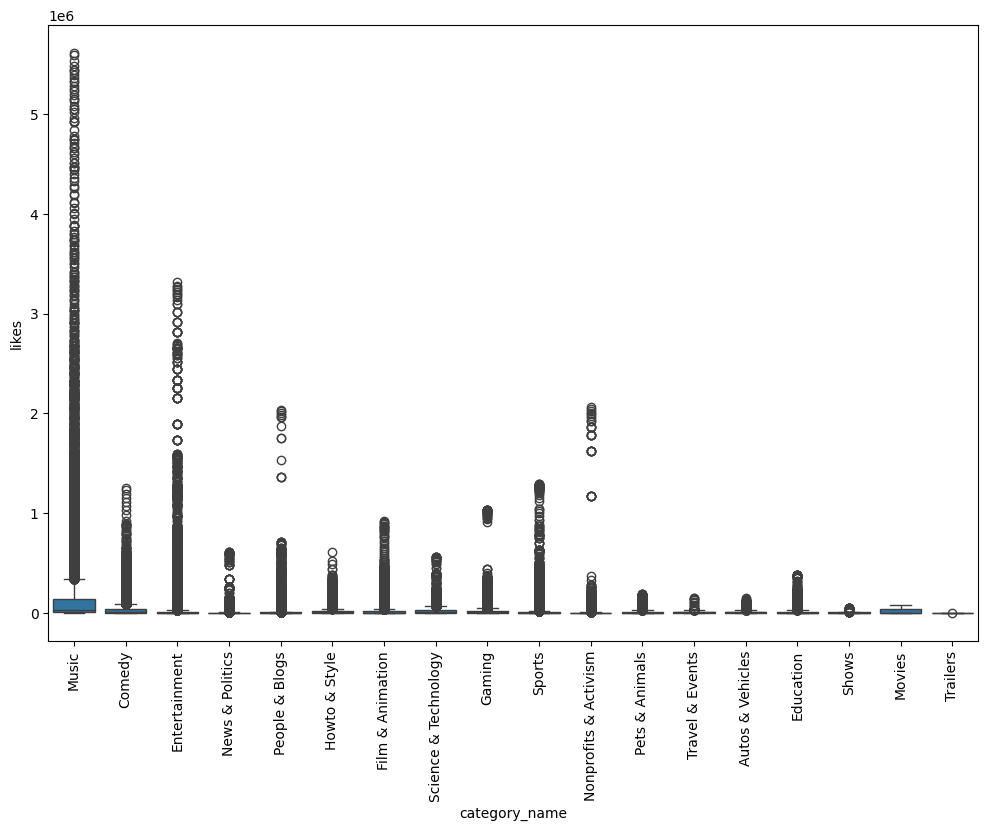

In [ ]:
plt.figure(figsize = (12, 8))
sns.boxplot(x = "category_name", y = "likes", data = full_df)
plt.xticks(rotation = "vertical")

## **Which channels have the largest number of trending videos?**

In [ ]:
full_df.head(6)

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,category_name
0,n1WpP7iowLc,17.14.11,Eminem - Walk On Water (Audio) ft. BeyoncÃ©,EminemVEVO,10,2017-11-10T17:00:03.000Z,"Eminem|""Walk""|""On""|""Water""|""Aftermath/Shady/In...",17158579,787425,43420,125882,https://i.ytimg.com/vi/n1WpP7iowLc/default.jpg,False,False,False,Eminem's new track Walk on Water ft. BeyoncÃ© ...,Music
1,0dBIkQ4Mz1M,17.14.11,PLUSH - Bad Unboxing Fan Mail,iDubbbzTV,23,2017-11-13T17:00:00.000Z,"plush|""bad unboxing""|""unboxing""|""fan mail""|""id...",1014651,127794,1688,13030,https://i.ytimg.com/vi/0dBIkQ4Mz1M/default.jpg,False,False,False,STill got a lot of packages. Probably will las...,Comedy
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146035,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO â¶ \n\nSUBSCRIBE âº ...,Comedy
3,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095828,132239,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...,Entertainment
4,2Vv-BfVoq4g,17.14.11,Ed Sheeran - Perfect (Official Music Video),Ed Sheeran,10,2017-11-09T11:04:14.000Z,"edsheeran|""ed sheeran""|""acoustic""|""live""|""cove...",33523622,1634130,21082,85067,https://i.ytimg.com/vi/2Vv-BfVoq4g/default.jpg,False,False,False,ð§: https://ad.gt/yt-perfect\nð°: https://...,Music
5,0yIWz1XEeyc,17.14.11,Jake Paul Says Alissa Violet CHEATED with LOGA...,DramaAlert,25,2017-11-13T07:37:51.000Z,"#DramaAlert|""Drama""|""Alert""|""DramaAlert""|""keem...",1309699,103755,4613,12143,https://i.ytimg.com/vi/0yIWz1XEeyc/default.jpg,False,False,False,âº Follow for News! - https://twitter.com/KEE...,News & Politics


In [ ]:
full_df['channel_title'].value_counts()

,count
channel_title,
The Late Show with Stephen Colbert,710
WWE,643
Late Night with Seth Meyers,592
TheEllenShow,555
Jimmy Kimmel Live,528
...,...
The Secrets of Dairy,1
babygranderecords,1
24 Oras News Today,1


In [ ]:
### lets obtain above frequency table using groupby approach :
cdf = full_df.groupby(['channel_title']).size().sort_values(ascending=False).reset_index()

In [ ]:
cdf = cdf.rename(columns={0:'total_videos'})

In [ ]:
cdf

,channel_title,total_videos
0,The Late Show with Stephen Colbert,710
1,WWE,643
2,Late Night with Seth Meyers,592
3,TheEllenShow,555
4,Jimmy Kimmel Live,528
...,...,...
37819,Tesoros Enterrados,1
37820,Anton Neverov,1
37821,Thalia 444,1
37822,Thaitv6 Official,1


In [ ]:
fig = px.bar(
    data_frame=cdf[0:20],
    x='channel_title',
    y='total_videos'
)

fig.update_layout(
    xaxis_tickangle=-45   # rotate labels
)

fig.show()

## **Which Category Dominates YouTube ?**

In [ ]:
full_df.dtypes

,0
video_id,object
trending_date,object
title,object
channel_title,object
category_id,int64
publish_time,object
tags,object
views,int64
likes,int64
dislikes,int64


In [ ]:
full_df["trending_date"]

,trending_date
0,17.14.11
1,17.14.11
2,17.14.11
3,17.14.11
4,17.14.11
...,...
375936,18.14.06
375938,18.14.06
375939,18.14.06
375940,18.14.06


In [ ]:
full_df["trending_date"] = pd.to_datetime(full_df["trending_date"], format = "%y.%d.%m")

In [ ]:
full_df.dtypes

,0
video_id,object
trending_date,datetime64[ns]
title,object
channel_title,object
category_id,int64
publish_time,object
tags,object
views,int64
likes,int64
dislikes,int64


In [ ]:
import json


In [ ]:
path = r"/content/drive/MyDrive/Text Data Analytics (Youtube Case-Study)/additional_data/US_category_id.json"

In [ ]:
with open(path, "r", encoding = "utf-8") as f:
  data = json.load(f)

In [ ]:
data

{'kind': 'youtube#videoCategoryListResponse',
 'etag': '"m2yskBQFythfE4irbTIeOgYYfBU/S730Ilt-Fi-emsQJvJAAShlR6hM"',
 'items': [{'kind': 'youtube#videoCategory',
   'etag': '"m2yskBQFythfE4irbTIeOgYYfBU/Xy1mB4_yLrHy_BmKmPBggty2mZQ"',
   'id': '1',
   'snippet': {'channelId': 'UCBR8-60-B28hp2BmDPdntcQ',
    'title': 'Film & Animation',
    'assignable': True}},
  {'kind': 'youtube#videoCategory',
   'etag': '"m2yskBQFythfE4irbTIeOgYYfBU/UZ1oLIIz2dxIhO45ZTFR3a3NyTA"',
   'id': '2',
   'snippet': {'channelId': 'UCBR8-60-B28hp2BmDPdntcQ',
    'title': 'Autos & Vehicles',
    'assignable': True}},
  {'kind': 'youtube#videoCategory',
   'etag': '"m2yskBQFythfE4irbTIeOgYYfBU/nqRIq97-xe5XRZTxbknKFVe5Lmg"',
   'id': '10',
   'snippet': {'channelId': 'UCBR8-60-B28hp2BmDPdntcQ',
    'title': 'Music',
    'assignable': True}},
  {'kind': 'youtube#videoCategory',
   'etag': '"m2yskBQFythfE4irbTIeOgYYfBU/HwXKamM1Q20q9BN-oBJavSGkfDI"',
   'id': '15',
   'snippet': {'channelId': 'UCBR8-60-B28hp2BmDPdnt

In [ ]:
data["items"][0]

{'kind': 'youtube#videoCategory',
 'etag': '"m2yskBQFythfE4irbTIeOgYYfBU/Xy1mB4_yLrHy_BmKmPBggty2mZQ"',
 'id': '1',
 'snippet': {'channelId': 'UCBR8-60-B28hp2BmDPdntcQ',
  'title': 'Film & Animation',
  'assignable': True}}

In [ ]:
data["items"][0]["snippet"]["title"]

'Film & Animation'

In [ ]:
data["items"][0]["id"]

'1'

In [ ]:
cat_dict = {}

for item in data["items"]:
  cat_dict[int(item["id"])] = item["snippet"]["title"]

In [ ]:
cat_dict

{1: 'Film & Animation',
 2: 'Autos & Vehicles',
 10: 'Music',
 15: 'Pets & Animals',
 17: 'Sports',
 18: 'Short Movies',
 19: 'Travel & Events',
 20: 'Gaming',
 21: 'Videoblogging',
 22: 'People & Blogs',
 23: 'Comedy',
 24: 'Entertainment',
 25: 'News & Politics',
 26: 'Howto & Style',
 27: 'Education',
 28: 'Science & Technology',
 29: 'Nonprofits & Activism',
 30: 'Movies',
 31: 'Anime/Animation',
 32: 'Action/Adventure',
 33: 'Classics',
 34: 'Comedy',
 35: 'Documentary',
 36: 'Drama',
 37: 'Family',
 38: 'Foreign',
 39: 'Horror',
 40: 'Sci-Fi/Fantasy',
 41: 'Thriller',
 42: 'Shorts',
 43: 'Shows',
 44: 'Trailers'}

In [ ]:
full_df["category_name"] = full_df["category_id"].map(cat_dict)

In [ ]:
full_df.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,category_name
0,n1WpP7iowLc,2017-11-14,Eminem - Walk On Water (Audio) ft. BeyoncÃ©,EminemVEVO,10,2017-11-10T17:00:03.000Z,"Eminem|""Walk""|""On""|""Water""|""Aftermath/Shady/In...",17158579,787425,43420,125882,https://i.ytimg.com/vi/n1WpP7iowLc/default.jpg,False,False,False,Eminem's new track Walk on Water ft. BeyoncÃ© ...,Music
1,0dBIkQ4Mz1M,2017-11-14,PLUSH - Bad Unboxing Fan Mail,iDubbbzTV,23,2017-11-13T17:00:00.000Z,"plush|""bad unboxing""|""unboxing""|""fan mail""|""id...",1014651,127794,1688,13030,https://i.ytimg.com/vi/0dBIkQ4Mz1M/default.jpg,False,False,False,STill got a lot of packages. Probably will las...,Comedy
2,5qpjK5DgCt4,2017-11-14,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146035,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO â¶ \n\nSUBSCRIBE âº ...,Comedy
3,d380meD0W0M,2017-11-14,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095828,132239,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...,Entertainment
4,2Vv-BfVoq4g,2017-11-14,Ed Sheeran - Perfect (Official Music Video),Ed Sheeran,10,2017-11-09T11:04:14.000Z,"edsheeran|""ed sheeran""|""acoustic""|""live""|""cove...",33523622,1634130,21082,85067,https://i.ytimg.com/vi/2Vv-BfVoq4g/default.jpg,False,False,False,ð§: https://ad.gt/yt-perfect\nð°: https://...,Music


In [ ]:
pivot_df = full_df.groupby(["trending_date", "category_name"])["views"].sum()

In [ ]:
pivot_df

trending_date  category_name       
2017-11-14     Autos & Vehicles          5449767
               Comedy                   92798793
               Education                 8625525
               Entertainment           233134424
               Film & Animation         59824388
                                         ...    
2018-06-14     Pets & Animals           16508451
               Science & Technology     19655174
               Shows                     2986906
               Sports                   58612762
               Travel & Events           2320638
Name: views, Length: 3290, dtype: int64

In [ ]:
pivot_df = full_df.groupby(["trending_date", "category_name"])["views"].sum().unstack(fill_value = 0)

In [ ]:
pivot_df

category_name,Autos & Vehicles,Comedy,Education,Entertainment,Film & Animation,Gaming,Howto & Style,Movies,Music,News & Politics,Nonprofits & Activism,People & Blogs,Pets & Animals,Science & Technology,Shows,Sports,Trailers,Travel & Events
trending_date,,,,,,,,,,,,,,,,,,
2017-11-14,5449767,92798793,8625525,233134424,59824388,20788680,39692396,0,522096451,22893805,1397585,69741490,3427634,19628265,1689318,34161599,0,1424022
2017-11-15,8050486,89048129,7072457,200761218,73620337,18302875,47173790,0,363498984,19512569,5363406,68342887,1684139,44572576,2456621,40823955,0,1487868
2017-11-16,7358437,82066922,7296205,215075485,78182533,18411174,36334035,0,336201790,21519797,4584043,47542853,2609618,39281789,1019265,46353999,0,2066936
2017-11-17,6436997,81766773,9328728,231929119,50794195,10147876,34707221,0,357949721,25304189,1377828,48916714,2068139,48763394,2433230,41649023,0,1001796
2017-11-18,7098844,80400958,8837341,217196554,64075205,10738066,29769264,0,369823307,26600320,2859005,45943293,4302877,77863217,3520947,33424799,0,1487049
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-06-10,3419469,92834235,7405034,541526503,120104266,70525231,63597826,0,1388065416,50320845,2267573,156067902,16377474,38192009,1764569,71436390,0,1855303
2018-06-11,4911969,93551035,10338600,505373442,119098102,74941508,62355833,0,1297630273,32512659,2739846,126699590,17112106,38183326,2122065,77764246,0,2108882
2018-06-12,5126438,109037786,9841181,482032248,135940594,108525939,54252824,0,943951258,35845162,3237080,128605502,15477174,30930795,2436709,57287168,0,2287951


In [ ]:
area_chart =px.area(
    data_frame = pivot_df,
    x = pivot_df.index,
    y = pivot_df.columns,
    title = "Trending Momentum Over Time by Category"
)

In [ ]:
area_chart

In [ ]:
top_categories = full_df.groupby(["category_name"])["views"].sum().nlargest(6).index

In [ ]:
top_categories

Index(['Music', 'Entertainment', 'Film & Animation', 'People & Blogs',
       'Comedy', 'Sports'],
      dtype='object', name='category_name')

In [ ]:
filtered_df = pivot_df[top_categories]

In [ ]:
area_chart =px.area(
    data_frame = filtered_df,
    x = filtered_df.index,
    y = filtered_df.columns,
    title = "Trending Momentum Over Time by Category"
)

In [ ]:
area_chart

## **Do Viral Videos Actually Get Engagement?**

In [ ]:
full_df.columns

Index(['video_id', 'trending_date', 'title', 'channel_title', 'category_id',
       'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count',
       'thumbnail_link', 'comments_disabled', 'ratings_disabled',
       'video_error_or_removed', 'description', 'category_name'],
      dtype='object')

In [ ]:
full_df["engagement_rate"] = (full_df["likes"] + full_df["comment_count"] ) / full_df["views"]

In [ ]:
bubble = px.scatter(full_df,
           x = "views",
           y = "engagement_rate",
           size = "comment_count",
           color = "category_name",
           hover_name = "title",
           title = "Engagement Bubble Map : Views Vs Engagement_rate",
           size_max = 60)

In [ ]:
bubble

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
bubble.update_xaxes(type = "log")

Output hidden; open in https://colab.research.google.com to view.

- Videos  with low - medium views has the `High Engagement`.
- Videos with very High view actually have the `Low Engagement`.

## **Views vs Engagement : Inside YouTube's Algorithm**

In [ ]:
full_df.columns

Index(['video_id', 'trending_date', 'title', 'channel_title', 'category_id',
       'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count',
       'thumbnail_link', 'comments_disabled', 'ratings_disabled',
       'video_error_or_removed', 'description', 'category_name',
       'engagement_rate'],
      dtype='object')

In [ ]:
category_matrics = full_df.groupby("category_name").agg(
                            total_views = ("views", "sum"),
                            avg_engagement_efficiency = ("engagement_rate", "mean"),
                            video_count = ("video_id", "count")).reset_index()

In [ ]:
category_matrics

,category_name,total_views,avg_engagement_efficiency,video_count
0,Autos & Vehicles,1514202384,0.049873,4596
1,Comedy,18341009925,0.058413,24024
2,Education,2485052061,0.057669,7396
3,Entertainment,85162066718,0.036217,97365
4,Film & Animation,20397383805,0.033448,18329
5,Gaming,6216418800,0.057708,10433
6,Howto & Style,8271658225,0.062121,17549
7,Movies,33047793,0.016044,22
8,Music,220389615568,0.051929,36990
9,News & Politics,8817653917,0.028820,34599


In [ ]:
treemap = px.treemap(
    category_matrics,
    path = ["category_name"],
    values = "total_views",
    color = "avg_engagement_efficiency",
    color_continuous_scale = "RdYlGn",
    title = "Category Attention Share with Engagement Efficiency Overlay",
    hover_data = {
        "total_views" : ":,.0f",
        "avg_engagement_efficiency" : ":.3f",
        "video_count" : True
    }
)

In [ ]:
treemap

## **Is the Audience Actually Engaged ?**

In order to figure out whether the audienece is engaged or not, we need to perform the `Descriptive Analysis`.

In [ ]:
full_df.columns

Index(['video_id', 'trending_date', 'title', 'channel_title', 'category_id',
       'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count',
       'thumbnail_link', 'comments_disabled', 'ratings_disabled',
       'video_error_or_removed', 'description', 'category_name',
       'engagement_rate'],
      dtype='object')

In [ ]:
full_df["engagement_rate"].describe()

,engagement_rate
count,339525.000000
mean,0.042103
std,0.043971
min,0.000000
25%,0.010395
50%,0.027453
75%,0.060261
max,0.957256


- `Low Average Engagement:`The mean engagement rate is 0.042 (≈4.2%), indicating that on average the engagement with content is relatively low.

- `High Variability :`The standard deviation is 0.0439, which is close to the mean.This suggests engagement varies significantly across posts/users.

- `Many Low Engagement Values:`The 25th percentile is 0.010 (≈1%), meaning 25% of posts have engagement below 1%.

- `Median Engagement:`The median (50%) is 0.027 (≈2.7%), which is lower than the mean.This indicates the distribution may be slightly right-skewed, with a few posts having high engagement.

- `Higher Engagement Segment:`The 75th percentile is 0.060 (≈6%), meaning only 25% of posts achieve engagement above 6%.

- `Extreme High Engagement:`The maximum value is 0.957 (≈95.7%), which is unusually high and may represent viral posts or potential outliers.

In [ ]:
category_engagement_stats = full_df.groupby("category_name")["engagement_rate"].describe()

In [ ]:
category_engagement_stats.sort_values("mean", ascending = False)

,count,mean,std,min,25%,50%,75%,max
category_name,,,,,,,,
Howto & Style,17549.0,0.062121,0.042688,0.000000,0.032948,0.052991,0.082680,0.709778
Science & Technology,7350.0,0.058860,0.053710,0.000000,0.024923,0.047330,0.077522,0.774282
Comedy,24024.0,0.058413,0.046692,0.000000,0.022036,0.048903,0.082108,0.746056
Gaming,10433.0,0.057708,0.048587,0.000000,0.022935,0.048472,0.078039,0.863608
Education,7396.0,0.057669,0.042375,0.000000,0.028697,0.050298,0.077079,0.445312
Music,36990.0,0.051929,0.045435,0.000000,0.021012,0.038634,0.067957,0.506464
Pets & Animals,4215.0,0.050707,0.039806,0.000000,0.023875,0.040444,0.066759,0.330806
Autos & Vehicles,4596.0,0.049873,0.035542,0.000000,0.024870,0.045179,0.068422,0.234820
Nonprofits & Activism,2722.0,0.049619,0.058793,0.000000,0.009192,0.023070,0.074042,0.704366


In [ ]:
box = px.box(full_df,
       x = "category_name",
       y = "engagement_rate",
       color = "category_name",
       title = "Audience engagement by Category")

In [ ]:
box

Output hidden; open in https://colab.research.google.com to view.